In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from textblob import TextBlob

In [3]:
df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 64.4 MB


In [5]:
df.isnull().sum()

Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

In [6]:
df["stock"].unique()

<StringArray>
[   'A',   'AA',  'AAC', 'AADR',  'AAL', 'AAMC', 'AAME',  'AAN', 'AAOI',
 'AAON',
 ...
 'ZOES', 'ZPIN',  'ZQK',  'ZSL', 'ZSPH',  'ZTR',  'ZTS',   'ZU', 'ZUMZ',
   'ZX']
Length: 6204, dtype: str

In [7]:
stocks = ["AAPL", "AMZN", "GOOG", "META", "NVDA"]

filtered_df = df[df["stock"].isin(stocks)]

filtered_df.head()

,Unnamed: 0,headline,url,publisher,date,stock
6680,7120,Tech Stocks And FAANGS Strong Again To Start D...,https://www.benzinga.com/government/20/06/1622...,JJ Kinahan,2020-06-10 11:33:26-04:00,AAPL
6681,7121,10 Biggest Price Target Changes For Wednesday,https://www.benzinga.com/analyst-ratings/price...,Lisa Levin,2020-06-10 08:14:08-04:00,AAPL
6682,7122,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",https://www.benzinga.com/short-sellers/20/06/1...,Benzinga Newsdesk,2020-06-10 07:53:47-04:00,AAPL
6683,7123,"Deutsche Bank Maintains Buy on Apple, Raises P...",https://www.benzinga.com/news/20/06/16219873/d...,Benzinga Newsdesk,2020-06-10 07:19:25-04:00,AAPL
6684,7124,Apple To Let Users Trade In Their Mac Computer...,https://www.benzinga.com/news/20/06/16218697/a...,Neer Varshney,2020-06-10 06:27:11-04:00,AAPL


In [8]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

filtered_df["clean_headline"] = filtered_df["headline"].apply(clean_text)

filtered_df[["headline", "clean_headline"]].head()

,headline,clean_headline
6680,Tech Stocks And FAANGS Strong Again To Start D...,tech stocks and faangs strong again to start d...
6681,10 Biggest Price Target Changes For Wednesday,biggest price target changes for wednesday
6682,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",benzinga pros top stocks to watch for wed jun...
6683,"Deutsche Bank Maintains Buy on Apple, Raises P...",deutsche bank maintains buy on apple raises pr...
6684,Apple To Let Users Trade In Their Mac Computer...,apple to let users trade in their mac computer...


In [9]:
filtered_df["sentiment"] = filtered_df["clean_headline"].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

filtered_df[["headline", "sentiment"]].head()

,headline,sentiment
6680,Tech Stocks And FAANGS Strong Again To Start D...,0.433333
6681,10 Biggest Price Target Changes For Wednesday,0.000000
6682,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",0.500000
6683,"Deutsche Bank Maintains Buy on Apple, Raises P...",0.000000
6684,Apple To Let Users Trade In Their Mac Computer...,0.000000


In [10]:
def label_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

filtered_df["sentiment_label"] = filtered_df["sentiment"].apply(label_sentiment)

filtered_df[["headline", "sentiment", "sentiment_label"]].head()

,headline,sentiment,sentiment_label
6680,Tech Stocks And FAANGS Strong Again To Start D...,0.433333,Positive
6681,10 Biggest Price Target Changes For Wednesday,0.000000,Neutral
6682,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",0.500000,Positive
6683,"Deutsche Bank Maintains Buy on Apple, Raises P...",0.000000,Neutral
6684,Apple To Let Users Trade In Their Mac Computer...,0.000000,Neutral


In [11]:
filtered_df["sentiment_label"].value_counts()

sentiment_label
Neutral     2930
Positive    1555
Negative     579
Name: count, dtype: int64

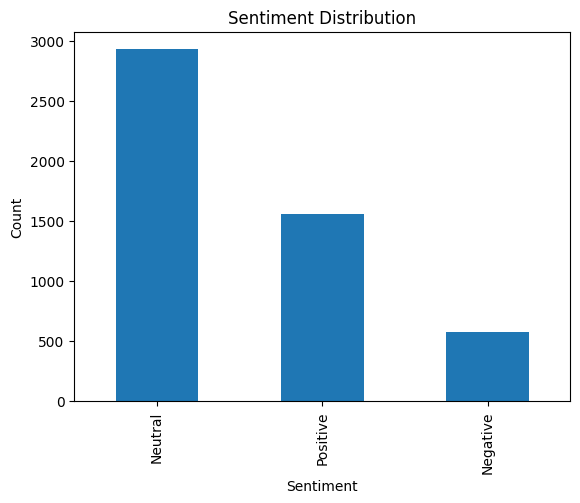

In [12]:
filtered_df["sentiment_label"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [16]:
filtered_df.to_csv("../data/processed/aapl_sentiment.csv", index=False)

print("File saved successfully!")

File saved successfully!


In [14]:
import os

os.makedirs("../data/processed", exist_ok=True)

print("Processed folder created!")

Processed folder created!


In [15]:
filtered_df.to_csv("../data/processed/aapl_sentiment.csv", index=False)

print("File saved successfully!")

File saved successfully!
